In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import torch

print("CUDA available:", torch.cuda.is_available())
print("Visible GPUs:", torch.cuda.device_count())
print("Using:", torch.cuda.get_device_name(0))

device = torch.device("cuda:0")
print("Device:", device)

import torch.nn.functional as F
from typing import Optional
import tempfile
import utils

CUDA available: True
Visible GPUs: 1
Using: Tesla V100S-PCIE-32GB
Device: cuda:0


In [2]:
def load_document_by_name(
    image_dir: Path,
    mask_dir: Path,
    image_name: str,
    image_exts=(".jpg", ".jpeg", ".png"),
    mask_ext=".png",
):
    """
    Load an image and its mask by file stem.

    Args:
        image_dir: Directory containing the images.
        mask_dir: Directory containing the masks.
        image_name: File stem without extension (e.g. 'cover_0001').
        image_exts: Allowed image extensions to search for.
        mask_ext: Expected mask extension.

    Returns:
        img_np: RGB image as a NumPy array.
        mask_np: Binary mask as a NumPy array.
        img_path: Resolved image path.
    """

    # Search for the image file using the allowed extensions
    img_path = None
    for ext in image_exts:
        p = image_dir / f"{image_name}{ext}"
        if p.exists():
            img_path = p
            break

    if img_path is None:
        raise FileNotFoundError(f"Image '{image_name}' not found in {image_dir}")

    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img)

    # Search for the corresponding mask
    mask_path = mask_dir / f"{image_name}{mask_ext}"
    if mask_path.exists():
        mask_np = np.array(Image.open(mask_path)).astype(np.int16)
        mask_np = (mask_np > 0).astype(np.int16)  # Binarize mask to {0, 1}
    else:
        # safe fallback: clean_image
        mask_np = np.zeros(img_np.shape[:2], dtype=np.int16)

    return img_np, mask_np, img_path

# DocTamper dataset

In [3]:
from models.doc_forgery_dataset_pep import DocForgeryDatasetPEP

In [4]:
def get_image_names(image_dir: Path):
    """
    Return sorted image file stems from a directory.

    Args:
        image_dir: Directory containing image files.

    Returns:
        A sorted list of file stems for .png images.
    """
    
    return sorted([p.stem for p in image_dir.glob("*.png")])

In [5]:
def overlay_mask_on_rgb(
    img_rgb: np.ndarray,
    mask: np.ndarray,
    alpha: float = 0.85,            # mais forte
    color_rgb=(255, 0, 0),
    ignore_value: int = -1,
    dilate_px: int = 7,             # engrossa só para ver (0 = sem)
    show_contours: bool = True,
    contour_thickness: int = 2,
):
    """
    Overlay a binary tampering mask on top of an RGB image.

    Args:
        img_rgb: RGB image as a NumPy array with shape [H, W, 3].
        mask: Mask array with shape [H, W].
        alpha: Overlay blending strength.
        color_rgb: RGB color used for the overlay.
        ignore_value: Optional ignore label in the mask.
        dilate_px: Dilation radius used only for visualization.
        show_contours: Whether to draw mask contours.
        contour_thickness: Thickness of the contour lines.

    Returns:
        The RGB image with the mask overlay.
    """
    
    assert img_rgb.ndim == 3 and img_rgb.shape[2] == 3
    
    H, W = img_rgb.shape[:2]
    if mask.shape[:2] != (H, W):
        raise ValueError(f"mask shape {mask.shape} != image shape {(H,W)}")

    m = mask.copy()

    # Positive region = tampered area
    if m.dtype == np.bool_:
        pos = m
    else:
        valid = (m != ignore_value) if np.any(m == ignore_value) else np.ones_like(m, dtype=bool)
        pos = (m > 0) & valid

    pos_u8 = (pos.astype(np.uint8) * 255)

    # Optional dilation used only to improve visibility
    if dilate_px and dilate_px > 0:
        k = 2 * dilate_px + 1
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        pos_u8 = cv2.dilate(pos_u8, kernel, iterations=1)

    pos2 = pos_u8.astype(bool)

    out = img_rgb.copy().astype(np.float32)
    color = np.array(color_rgb, dtype=np.float32).reshape(1, 1, 3)
    out[pos2] = (1 - alpha) * out[pos2] + alpha * color
    out = np.clip(out, 0, 255).astype(np.uint8)

    if show_contours:
        contours, _ = cv2.findContours(pos_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, contours, -1, (255, 255, 0), contour_thickness)  # amarelo

    return out

In [6]:
def show_and_save_full_image_mask_overlay(
    img_rgb: np.ndarray,
    mask: np.ndarray,
    alpha=0.85,
    dilate_px=7,
    figsize=(18, 6),
):
    """
    Display and save the original image, mask, and overlay visualization.

    Args:
        img_rgb: RGB image as a NumPy array.
        mask: Binary mask as a NumPy array.
        alpha: Overlay blending strength.
        dilate_px: Dilation radius used only for visualization.
        figsize: Figure size.
    """
    
    overlay = overlay_mask_on_rgb(img_rgb, mask, alpha=alpha, dilate_px=dilate_px)

    fig, ax = plt.subplots(1, 3, figsize=figsize)
    ax[0].imshow(img_rgb)
    ax[0].set_title(f"Image")
    ax[0].axis("off")
    
    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title(f"Mask")
    ax[1].axis("off")
    
    ax[2].imshow(overlay)
    ax[2].set_title(f"Overlay")
    ax[2].axis("off")
    
    plt.tight_layout()
    
    save_path = "inspection_pngs_doctamper_rtm/doctamper_visualization_doc_tamper_400.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    
    plt.show()
    print("saved to:", save_path)

In [7]:
train_image_dir = Path("/media/general_storage6/rmastorage/datasets/doc-tamper/DocTamperV1-FCD/tampered")
train_mask_dir = Path("/media/general_storage6/rmastorage/datasets/doc-tamper/DocTamperV1-FCD/mask")

In [8]:
train_image_names = get_image_names(train_image_dir)

In [9]:
len(train_image_names)

2000

In [10]:
train_image_name = "doc_tamper_400"

In [11]:
train_img, train_mask, train_image_path = load_document_by_name(
    image_dir=train_image_dir,
    mask_dir=train_mask_dir,
    image_name=train_image_name,
)

In [12]:
print("Loaded:", train_image_path)
print("Image shape:", train_img.shape)
print("Mask shape:", train_mask.shape)

Loaded: /media/general_storage6/rmastorage/datasets/doc-tamper/DocTamperV1-FCD/tampered/doc_tamper_400.png
Image shape: (512, 512, 3)
Mask shape: (512, 512)


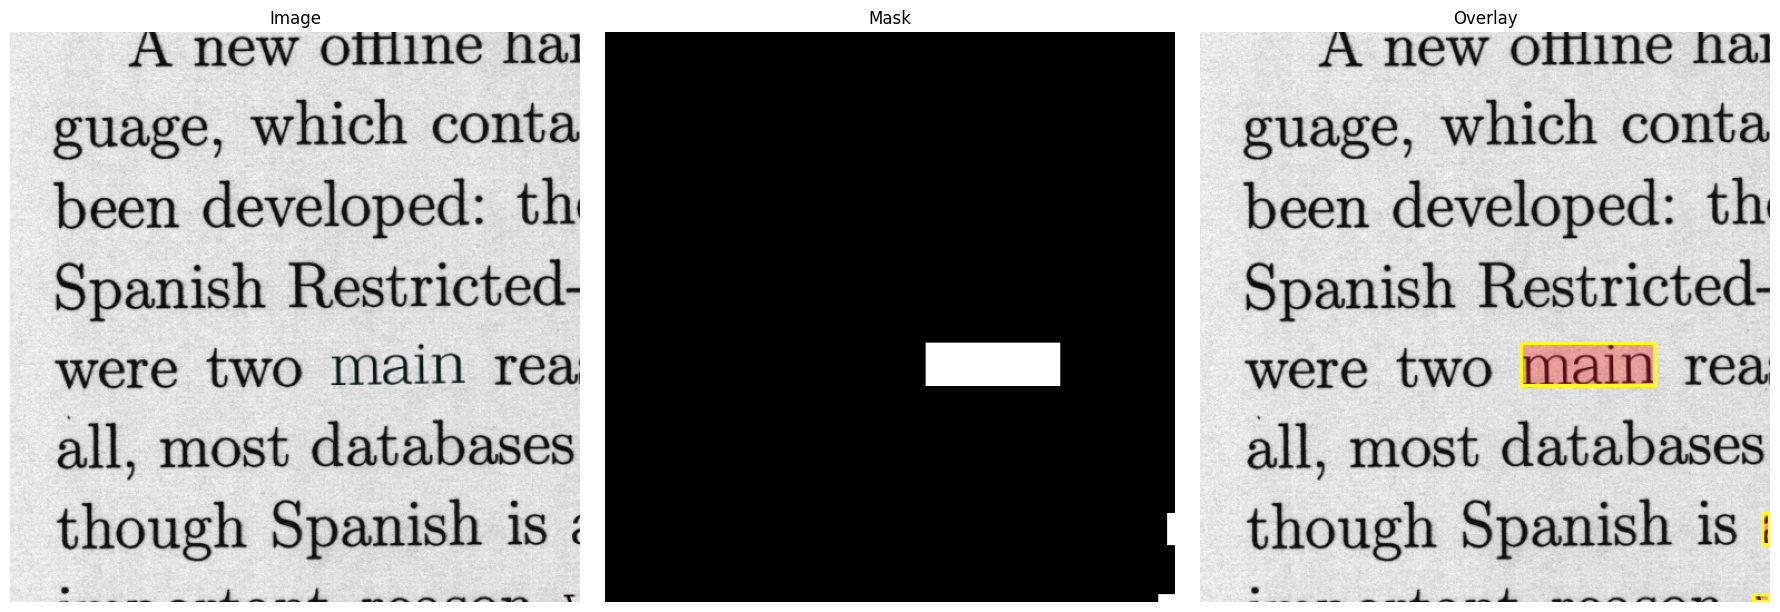

saved to: outputs_check_channels/doctamper_visualization_doc_tamper_400.png


In [13]:
show_and_save_full_image_mask_overlay(train_img, train_mask, alpha=0.30, dilate_px=0)

In [14]:
def compute_pep_with_qf2_from_png(
    img_path: str,
    origin=(0, 0),
    crop_size=None,
    qf2: int = 98,
    qf_pep: int = 90,
):
    """
    Compute PEP for DocTamper PNG images by simulating a JPEG compression step first.

    Pipeline:
        1. Load the PNG image
        2. Convert it to JPEG using qf2
        3. Extract DCT coefficients and quantization tables from that JPEG
        4. Compute PEP using qf_pep

    This approximates the scenario:
        original PNG -> assumed JPEG compression with QF2 -> PEP

    Args:
        img_path: Path to the input PNG image.
        origin: Top-left corner of the crop.
        crop_size: Optional crop size.
        qf2: JPEG quality factor used before PEP.
        qf_pep: Quality factor used inside PEP.

    Returns:
        pep: PEP map as a NumPy array.
    """
    
    img = Image.open(img_path).convert("RGB")

    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
        tmp_path = tmp.name

    try:
        # Apply JPEG compression before PEP
        img.save(
            tmp_path, 
            "JPEG", 
            quality=int(qf2), 
            subsampling=0, 
            optimize=False,
        )

        DCT_coef, qtables = utils.get_jpeg_info(tmp_path, 1)
        DCT_y = np.array(DCT_coef[0])
        qt_y = qtables[0]

        pep_t = DocForgeryDatasetPEP.pep_features(
            image_path=Path(tmp_path),
            dct=DCT_y,
            qtable=qt_y,
            origin=origin,
            crop_size=crop_size,
            qf_pep=int(qf_pep),  #90
        )

        pep = pep_t[0].detach().cpu().numpy()
        return pep

    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

In [15]:
pep_np = compute_pep_with_qf2_from_png(
    img_path=train_image_path,
    origin=(0,0),
    crop_size=(512, 512),
    qf2=98,
    qf_pep=90,
)

print("pep_np:", pep_np.shape, pep_np.dtype, pep_np.min(), pep_np.max())

pep_np: (512, 512) float32 0.0 1.0


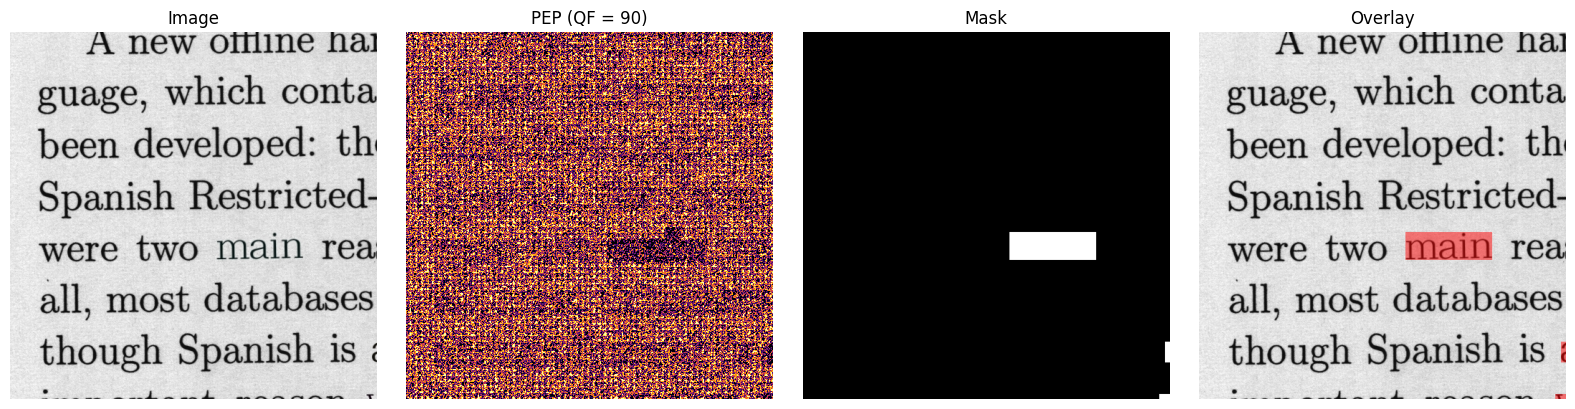

saved to: outputs_check_channels/doctamper_pep_visualization_doc_tamper_400.png


In [16]:
gt = (train_mask == 1).astype(np.uint8)

plt.figure(figsize=(16,4))
plt.subplot(1,4,1); plt.imshow(train_img); plt.title("Image"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(pep_np, cmap="inferno"); plt.title("PEP (QF = 90)"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(gt, cmap="gray"); plt.title("Mask"); plt.axis("off")

overlay = train_img.copy()
overlay[gt==1] = (overlay[gt==1]*0.5 + np.array([255,0,0])*0.5).astype(np.uint8)
plt.subplot(1,4,4); plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")

plt.tight_layout()

save_path = "inspection_pngs_doctamper_rtm/doctamper_pep_visualization_doc_tamper_400.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")

plt.show()
print("saved to:", save_path)

In [17]:
def sweep_qfs_grid_doctamper(
    img_rgb: np.ndarray,
    mask: np.ndarray,
    qf2_list=(97, 98, 99, 100),
    qfs_pep_list=(50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100),
    dpi=160,
    save_dir=None,
    save_prefix="sweep",
    save_format="png",
    show=True,
):
    """
    Run a grid sweep for DocTamper using QF2 and QF_PEP.

    Rows correspond to QF2 values.
    Columns correspond to QF_PEP values.

    Pipeline:
        PNG -> JPEG(QF2) -> PEP(QF_PEP)

    Displays:
        RGB | PEP

    Args:
        img_rgb: Input RGB image as a NumPy array.
        mask: Input mask (not used in the current visualization).
        qf2_list: List of JPEG quality factors used before PEP.
        qfs_pep_list: List of quality factors used for PEP.
        dpi: Output figure DPI.
        save_dir: Directory where the figure will be saved.
        save_prefix: Prefix used for the output filename.
        save_format: Output image format.
        show: Whether to display the figure.

    Returns:
        saved_path: Output file path if saved, otherwise None.
    """
    
    qf2_list = list(qf2_list)
    qfs_pep_list = list(qfs_pep_list)

    nrows = len(qf2_list)
    ncols = len(qfs_pep_list)
    n_panels = 2  # RGB, PEP

    fig, ax = plt.subplots(
        nrows * n_panels,
        ncols,
        figsize=(3.6 * ncols, 2.8 * nrows * n_panels),
        dpi=dpi
    )

    if nrows * n_panels == 1 and ncols == 1:
        ax = np.array([[ax]])
    elif ncols == 1:
        ax = np.expand_dims(ax, 1)
    elif nrows * n_panels == 1:
        ax = np.expand_dims(ax, 0)

    for r, qf2 in enumerate(qf2_list):
        for c, qf_pep in enumerate(qfs_pep_list):
            tmp_path = None
            try:
                with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
                    tmp_path = tmp.name

                Image.fromarray(img_rgb).save(
                    tmp_path,
                    "JPEG",
                    quality=int(qf2),
                    subsampling=0,
                    optimize=False,
                )

                img_used = np.array(Image.open(tmp_path).convert("RGB"), dtype=np.uint8)

                DCT_coef, qtables = utils.get_jpeg_info(tmp_path, 1)
                DCT_y = np.array(DCT_coef[0])
                qt_y = qtables[0]

                pep_t = DocForgeryDatasetPEP.pep_features(
                    image_path=Path(tmp_path),
                    dct=DCT_y,
                    qtable=qt_y,
                    origin=(0, 0),
                    crop_size=None,
                    qf_pep=int(qf_pep),
                )
                pep = pep_t[0].detach().cpu().numpy()

                visuals = [
                    ("Image", img_used, {}),
                    (f"PEP qf={qf_pep}", pep, {"cmap": "magma"}),
                ]

                for k, (title, vis, kwargs) in enumerate(visuals):
                    rr = r * n_panels + k
                    ax[rr, c].imshow(vis, **kwargs)
                    ax[rr, c].axis("off")
                    ax[rr, c].set_title(title, fontsize=8, pad=2)

                    if r == 0 and k == 0:
                        ax[rr, c].text(
                            0.5, 1.18, f"QF_PEP={qf_pep}",
                            transform=ax[rr, c].transAxes,
                            ha="center",
                            va="bottom",
                            fontsize=11,
                            fontweight="bold",
                        )

                    if c == 0 and k == 0:
                        ax[rr, c].text(
                            -0.22, 0.5, f"QF2={qf2}",
                            transform=ax[rr, c].transAxes,
                            ha="right",
                            va="center",
                            fontsize=10,
                            fontweight="bold",
                        )

            finally:
                if tmp_path is not None and os.path.exists(tmp_path):
                    os.remove(tmp_path)

    #fig.suptitle(
    #    "DocTamper Sweep | QF2 x QF_PEP",
    #    fontsize=16,
    #    y=0.995
    #)
    plt.tight_layout(rect=[0, 0, 1, 0.985])

    saved_path = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        qf2_min, qf2_max = min(qf2_list), max(qf2_list)
        qfpep_min, qfpep_max = min(qfs_pep_list), max(qfs_pep_list)

        out_name = (
            f"{save_prefix}"
            f"qf2_{qf2_min}-{qf2_max}_"
            f"qfpep_{qfpep_min}-{qfpep_max}"
            f".{save_format}"
        )

        out_path = save_dir / out_name
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        saved_path = str(out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path

In [18]:
saved_path = sweep_qfs_grid_doctamper(
    img_rgb=train_img,
    mask=train_mask,
    qf2_list=(97, 98, 99, 100),
    qfs_pep_list=(80, 85, 90, 95, 100),
    save_dir="inspection_pngs_doctamper_rtm",
    save_prefix="doctamper_doc_tamper_400_sweep_",
    show=False,
)

print(saved_path)

outputs_check_channels/doctamper_doc_tamper_400_sweep_qf2_97-100_qfpep_80-100.png


# RTM Dataset

In [19]:
from models.doc_forgery_dataset_ela_pep_rtm import DocForgeryELAPEPDataset

In [20]:
train_image_dir = Path("/media/general_storage6/rmastorage/datasets/RealTextManipulation/train_v2/JPEGImages")
train_mask_dir = Path("/media/general_storage6/rmastorage/datasets/RealTextManipulation/train_v2/SegmentationClass")

In [21]:
def get_image_names(image_dir: Path):
    """
    Return sorted image file stems from a directory.

    Args:
        image_dir: Directory containing image files.

    Returns:
        A sorted list of file stems for .jpg images.
    """
    
    return sorted([p.stem for p in image_dir.glob("*.jpg")])

In [22]:
train_image_names = get_image_names(train_image_dir)

In [23]:
len(train_image_names)

7200

In [24]:
TYPES = ["good", "cover", "cpmv", "edit", "inpaint", "insert", "splice"]

def show_and_save_full_image_mask_overlay_by_type(
    images_by_type: dict,
    masks_by_type: dict,
    alpha=0.30,
    dilate_px=0,
    save_path="inspection_pngs_doctamper_rtm/rtm_visualization_all_types.png",
):
    """
    Display and save image, mask, and overlay visualizations for all document types.

    Each row corresponds to one document type.
    The three columns are:
        1. RGB image
        2. Binary mask
        3. Mask overlay on the RGB image

    Args:
        images_by_type: Dictionary mapping document type to RGB image.
        masks_by_type: Dictionary mapping document type to mask.
        alpha: Overlay blending strength.
        dilate_px: Dilation radius used only for visualization.
        save_path: Output path for the saved figure.
    """
    
    n_rows = len(TYPES)

    fig, ax = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))

    # Special case: only one row
    if n_rows == 1:
        ax = np.expand_dims(ax, axis=0)

    for i, doc_type in enumerate(TYPES):
        img_rgb = images_by_type[doc_type]
        mask = masks_by_type[doc_type]

        overlay = overlay_mask_on_rgb(img_rgb, mask, alpha=alpha, dilate_px=dilate_px)

        ax[i, 0].imshow(img_rgb)
        ax[i, 0].set_title(f"Image {doc_type}")
        ax[i, 0].axis("off")

        ax[i, 1].imshow(mask, cmap="gray")
        ax[i, 1].set_title(f"Mask {doc_type}")
        ax[i, 1].axis("off")

        ax[i, 2].imshow(overlay)
        ax[i, 2].set_title(f"Overlay {doc_type}")
        ax[i, 2].axis("off")

    plt.tight_layout()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    print("saved to:", save_path)

In [25]:
train_image_name_good = "good_1103"
train_image_name_cover = "cover_0230"
train_image_name_cpmv = "cpmv_2015"
train_image_name_edit = "edit_0220"
train_image_name_inpaint = "inpaint_0701"
train_image_name_insert = "insert_0069"
train_image_name_splice = "splice_0026"

In [26]:
# carregar
train_img_good, train_mask_good, train_path_good = load_document_by_name(train_image_dir, train_mask_dir, train_image_name_good)
train_img_cover, train_mask_cover, train_path_cover = load_document_by_name(train_image_dir, train_mask_dir, train_image_name_cover)
train_img_cpmv, train_mask_cpmv, train_path_cpmv = load_document_by_name(train_image_dir, train_mask_dir, train_image_name_cpmv)
train_img_edit, train_mask_edit, train_path_edit = load_document_by_name(train_image_dir, train_mask_dir, train_image_name_edit)
train_img_inpaint, train_mask_inpaint, train_path_inpaint = load_document_by_name(train_image_dir, train_mask_dir, train_image_name_inpaint)
train_img_insert, train_mask_insert, train_path_insert = load_document_by_name(train_image_dir, train_mask_dir, train_image_name_insert)
train_img_splice, train_mask_splice, train_path_splice = load_document_by_name(train_image_dir, train_mask_dir, train_image_name_splice)

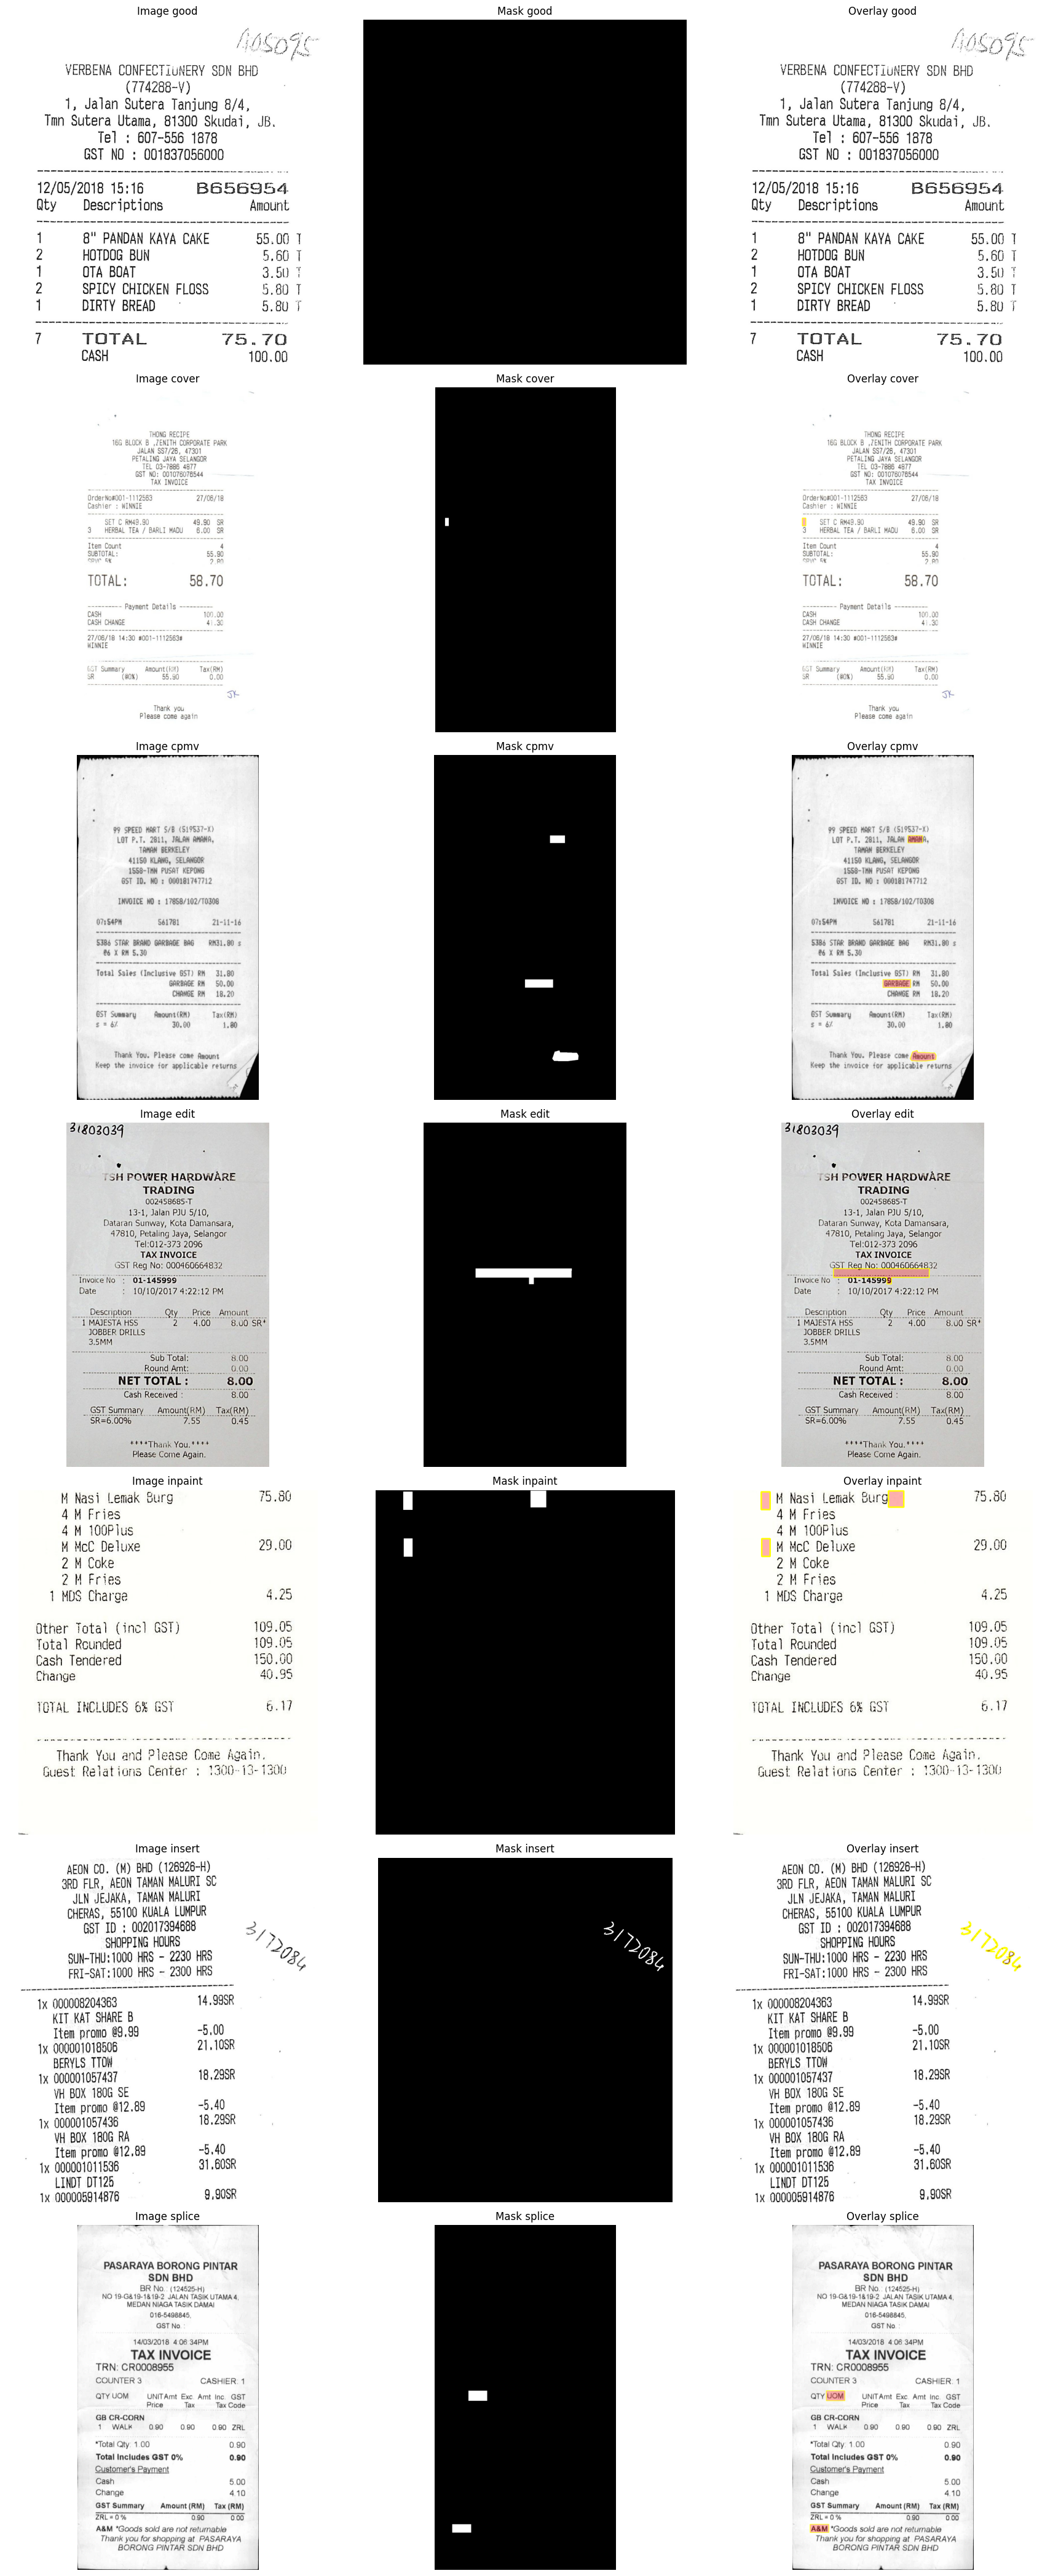

saved to: outputs_check_channels/rtm_visualization_all_types.png


In [27]:
images_by_type = {
    "good": train_img_good,
    "cover": train_img_cover,
    "cpmv": train_img_cpmv,
    "edit": train_img_edit,
    "inpaint": train_img_inpaint,
    "insert": train_img_insert,
    "splice": train_img_splice,
}

masks_by_type = {
    "good": train_mask_good,
    "cover": train_mask_cover,
    "cpmv": train_mask_cpmv,
    "edit": train_mask_edit,
    "inpaint": train_mask_inpaint,
    "insert": train_mask_insert,
    "splice": train_mask_splice,
}

show_and_save_full_image_mask_overlay_by_type(images_by_type, masks_by_type)

In [28]:
print("Loaded:", train_path_cpmv)
print("Image shape:", train_img_cpmv.shape)
print("Mask shape:", train_mask_cpmv.shape)

Loaded: /media/general_storage6/rmastorage/datasets/RealTextManipulation/train_v2/JPEGImages/cpmv_2015.jpg
Image shape: (1684, 888, 3)
Mask shape: (1684, 888)


In [29]:
def compute_pep_from_original_jpeg(
    img_path: str,
    origin=(0,0),
    crop_size=None,
    qf_pep: int = 90,
):
    """
    Compute PEP using the DCT coefficients and quantization table
    from the original JPEG image.

    crop_size should be a multiple of 8 when using grid_crop.

    Args:
        img_path: Path to the original JPEG image.
        origin: Top-left corner of the crop.
        crop_size: Crop size to use for PEP extraction.
        qf_pep: Quality factor used inside PEP.

    Returns:
        pep: PEP map as a NumPy array.
    """
    
    # Extract DCT coefficients and quantization table from the original JPEG
    DCT_coef, qtables = utils.get_jpeg_info(img_path, 1)
    DCT_y = np.array(DCT_coef[0])  
    qt_y  = qtables[0]          

    H, W = DCT_y.shape

    # If full-image PEP is requested, use the full DCT shape
    # In the current code, DCT shape is assumed to match crop_size
    if crop_size is None:
        crop_size = (H, W)

    print(type(DCT_coef), len(DCT_coef))
    print(type(qtables), len(qtables))
    print("DCT_y shape:", DCT_y.shape)
    print("qt_y shape:", np.array(qt_y).shape)
    print("crop_size:", crop_size)
    print("origin:", origin)
    
    pep_t = DocForgeryELAPEPDataset.pep_features(
        image_path=Path(img_path),
        dct=DCT_y,
        qtable=qt_y,
        origin=origin,
        crop_size=crop_size,
        qf_pep=int(qf_pep),  #90
    )
    pep = pep_t[0].detach().cpu().numpy()  # [Hc,Wc]
    return pep

In [30]:
pep_np = compute_pep_from_original_jpeg(
    img_path=train_path_cpmv,
    origin=(0,0),
    crop_size=None,
    qf_pep=90
)

print("pep_np:", pep_np.shape, pep_np.dtype, "min/max:", pep_np.min(), pep_np.max())

<class 'list'> 1
<class 'list'> 1
DCT_y shape: (1688, 888)
qt_y shape: (8, 8)
crop_size: (1688, 888)
origin: (0, 0)
pep_np: (1688, 888) float32 min/max: 0.0 1.0


In [31]:
def compute_ela(img_rgb_uint8: np.ndarray, qf_ela: int):
    """
    Compute ELA from an RGB uint8 image.

    Args:
        img_rgb_uint8: RGB image as a NumPy array with dtype uint8.
        qf_ela: JPEG quality factor used for ELA.

    Returns:
        ela: ELA map as an HWC NumPy array.
    """
    
    t = DocForgeryELAPEPDataset.ela_features(
        image=Image.fromarray(img_rgb_uint8).convert("RGB"),
        origin=(0,0),
        crop_size=None,
        qf_ela=int(qf_ela),
    )  # [3,H,W] float
    
    ela = t.detach().cpu().numpy().transpose(1,2,0) # Convert to HWC
    return ela

In [32]:
ela_np = compute_ela(train_img_cpmv, qf_ela=89) #qf_ela = 89 (QF = QF3 = 90)

In [33]:
def compute_hp_edge(rgb_01):
    """
    Compute high-pass and edge auxiliary channels.

    Accepted inputs:
        - NumPy array with shape [H, W, 3]
        - Torch tensor with shape [H, W, 3]
        - Torch tensor with shape [1, 3, H, W]

    Returns:
        aux: Tensor with shape [B, 2, H, W]
             containing:
             - high-pass grayscale channel in [0, 1]
             - edge magnitude channel in [0, 1]
    """
    
    if isinstance(rgb_01, np.ndarray):
        rgb_01 = torch.from_numpy(rgb_01).float() / 255.0
        rgb_01 = rgb_01.permute(2, 0, 1).unsqueeze(0)

    elif isinstance(rgb_01, torch.Tensor):
        if rgb_01.ndim == 3 and rgb_01.shape[-1] == 3:   # [H,W,3]
            rgb_01 = rgb_01.float()
            if rgb_01.max() > 1:
                rgb_01 = rgb_01 / 255.0
            rgb_01 = rgb_01.permute(2, 0, 1).unsqueeze(0)

        elif rgb_01.ndim == 4:  # [B,3,H,W]
            rgb_01 = rgb_01.float()
            if rgb_01.max() > 1:
                rgb_01 = rgb_01 / 255.0
        else:
            raise ValueError(f"Shape não suportado: {rgb_01.shape}")

    else:
        raise TypeError(f"Tipo não suportado: {type(rgb_01)}")

    r, g, b = rgb_01[:, 0:1], rgb_01[:, 1:2], rgb_01[:, 2:3]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b

    # Simple blur for stable high-pass extraction
    blur = F.avg_pool2d(gray, kernel_size=7, stride=1, padding=3)
    hp = gray - blur
    hp = torch.clamp(hp, -0.5, 0.5)
    hp_01 = hp + 0.5

    # Sobel edge magnitude
    kx = torch.tensor(
        [[-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]], 
        device=gray.device, 
        dtype=gray.dtype
    ).view(1, 1, 3, 3)
    
    ky = torch.tensor(
        [[-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]], 
        device=gray.device, 
        dtype=gray.dtype
    ).view(1, 1, 3, 3)

    gx = F.conv2d(gray, kx, padding=1)
    gy = F.conv2d(gray, ky, padding=1)
    mag = torch.sqrt(gx * gx + gy * gy + 1e-6)

    edge_01 = torch.clamp(mag / 4.0, 0.0, 1.0)

    aux = torch.cat([hp_01, edge_01], dim=1)
    return aux

In [34]:
aux = compute_hp_edge(train_img_cpmv)

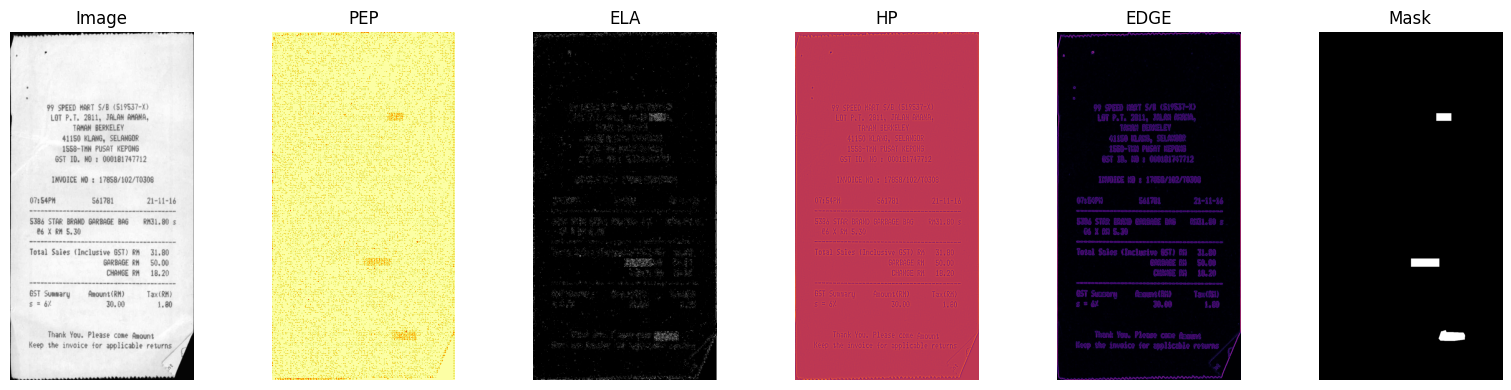

saved to: outputs_check_channels/rtm_pep_ela_2aux_full_visualization_cpmv_2015.png


In [35]:
hp_channel = aux[:,0:1]
edge_channel = aux[:,1:2]

plt.figure(figsize=(16,4))
plt.subplot(1,6,1); plt.imshow(train_img_cpmv); plt.title("Image"); plt.axis("off")
plt.subplot(1,6,2); plt.imshow(pep_np, cmap="inferno"); plt.title("PEP"); plt.axis("off")
plt.subplot(1,6,3); plt.imshow(ela_np, cmap="inferno"); plt.title("ELA"); plt.axis("off")
plt.subplot(1,6,4); plt.imshow(hp_channel[0,0].detach().cpu(), cmap="inferno"); plt.title("HP"); plt.axis("off")
plt.subplot(1,6,5); plt.imshow(edge_channel[0,0].detach().cpu(), cmap="inferno"); plt.title("EDGE"); plt.axis("off")
plt.subplot(1,6,6); plt.imshow(train_mask_cpmv, cmap="gray"); plt.title("Mask"); plt.axis("off")

plt.tight_layout()

save_path = "inspection_pngs_doctamper_rtm/rtm_pep_ela_2aux_full_visualization_cpmv_2015.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")

plt.show()
print("saved to:", save_path)

In [36]:
def draw_rectangles(img, rects, color=(0,255,0), thickness=2):
    """
    Draw rectangles on an RGB image.

    Args:
        img: Input image.
        rects: List of rectangles in (y, x, h, w) format.
        color: Rectangle color in BGR/RGB tuple format, depending on the image convention.
        thickness: Rectangle border thickness.

    Returns:
        out: Image with rectangles drawn.
    """
    
    out = img.copy()
    
    for (y,x,h,w) in rects:
        cv2.rectangle(out, (x,y), (x+w, y+h), color, thickness)
        
    return out

In [37]:
def draw_rectangles_on_mask(mask, rects, thickness=2):
    """
    Draw rectangles on a binary mask for visualization.

    Args:
        mask: Input binary mask.
        rects: List of rectangles in (y, x, h, w) format.
        thickness: Rectangle border thickness.

    Returns:
        out: 3-channel visualization image with rectangles drawn on the mask.
    """

    # Convert mask to 0..255 for visualization
    out = (mask.astype(np.uint8) * 255)
    out = cv2.cvtColor(out, cv2.COLOR_GRAY2BGR)
    
    for (y,x,h,w) in rects:
        cv2.rectangle(out, (x,y), (x+w, y+h), (255,255,255), thickness)
        
    return out

In [38]:
def generate_all_crops_from_image(
    image_path: str,
    mask_np: np.ndarray,
    crop_size=(512, 512),
    stride=None,
    ignore_index=-1,
):
    """
    Generate all grid crops from an image, including the final crops
    needed to cover the image borders.

    Returns:
        rects: List of rectangles in (y, x, h, w) format
        crops: List of dictionaries with:
               - "img_crop_np": cropped RGB image as HWC uint8
               - "mask_crop_np": cropped mask as HW int16
        metas: List of metadata dictionaries with:
               - "origin": crop origin
               - "is_pos": positive/tampered flag
               - "tampered_ratio": tampered area ratio
        ys: Grid y-coordinates
        xs: Grid x-coordinates
        hw: Full image size as (H, W)

    Args:
        image_path: Path to the full image.
        mask_np: Full mask as a NumPy array.
        crop_size: Crop size as (height, width).
        stride: Grid stride. If None, stride = crop height.
        ignore_index: Ignore label used in the mask.

    Returns:
        rects, crops, metas, ys, xs, (H, W)
    """
    
    crop_h, crop_w = crop_size

    with Image.open(image_path) as im:
        W, H = im.size

    if stride is None:
        stride = crop_h

    ys = list(range(0, max(1, H - crop_h + 1), stride))
    xs = list(range(0, max(1, W - crop_w + 1), stride))

    if len(ys) == 0:
        ys = [0]
    if len(xs) == 0:
        xs = [0]

    last_y = max(0, H - crop_h)
    last_x = max(0, W - crop_w)

    if ys[-1] != last_y:
        ys.append(last_y)
    if xs[-1] != last_x:
        xs.append(last_x)

    rects, crops, metas = [], [], []

    for y in ys:
        for x in xs:
            img_crop_np, mask_crop_np, is_pos, tampered_ratio = DocForgeryELAPEPDataset.crop_at_origin_with_pad(
                image_path=image_path,
                mask=mask_np,
                origin=(y, x),
                crop_size=crop_size,
                ignore_index=ignore_index,
            )

            rects.append((y, x, crop_h, crop_w))
            crops.append({
                "img_crop_np": img_crop_np,
                "mask_crop_np": mask_crop_np,
            })
            metas.append({
                "origin": (int(y), int(x)),
                "is_pos": int(is_pos),
                "tampered_ratio": float(tampered_ratio),
            })

    return rects, crops, metas, ys, xs, (H, W)

In [39]:
def pick_most_relevant_crop(rects, crops, metas, mode="max"):
    """
    Select the most relevant crop based on tampered ratio.

    Args:
        rects: List of crop rectangles in (y, x, h, w) format.
        crops: List of crop dictionaries.
        metas: List of metadata dictionaries.
        mode:
            - "max": select the crop with the highest tampered_ratio
            - "min": select the crop with the lowest tampered_ratio

    Returns:
        idx: Selected crop index.
        rects[idx]: Selected rectangle.
        crops[idx]: Selected crop dictionary.
        metas[idx]: Selected metadata dictionary.
    """
    
    ratios = [m["tampered_ratio"] for m in metas]
    if len(ratios) == 0:
        raise ValueError("No crops available to choose from.")
        
    idx = int(np.argmax(ratios) if mode == "max" else np.argmin(ratios))
    return idx, rects[idx], crops[idx], metas[idx]

In [40]:
def show_best_crop_only(
    image_path: str,
    image_np: np.ndarray,
    mask_np: np.ndarray,
    crop_size=(512, 512),
    stride=None,
    ignore_index=-1,
    pick_mode="max",           # "max" ou "min"
    figsize_full=(16, 10),
    figsize_crop=(10, 4),
):
    """
    Generate all grid crops, select the most relevant one, and visualize it.

    The function:
        1. Generates all crops from the image grid
        2. Selects the most relevant crop
        3. Draws the selected rectangle on the full image and full mask
        4. Displays the full image/mask and the selected crop/mask

    Args:
        image_path: Path to the full image.
        image_np: Full RGB image as a NumPy array.
        mask_np: Full mask as a NumPy array.
        crop_size: Crop size as (height, width).
        stride: Grid stride. If None, defaults to crop height.
        ignore_index: Ignore label used in the mask.
        pick_mode:
            - "max": choose crop with maximum tampered_ratio
            - "min": choose crop with minimum tampered_ratio
        figsize_full: Figure size for full-image visualization.
        figsize_crop: Figure size for crop visualization.

    Returns:
        A dictionary containing:
            - best_idx
            - rect
            - crop
            - meta
            - all_rects
            - all_metas
            - ys
            - xs
            - hw
    """
    
    # 1) Generate all crops from the grid
    rects, crops, metas, ys, xs, hw = generate_all_crops_from_image(
        image_path=image_path,
        mask_np=mask_np,
        crop_size=crop_size,
        stride=stride,
        ignore_index=ignore_index,
    )

    # 2) Select the most relevant crop
    idx, (y, x, h, w), crop_dict, meta = pick_most_relevant_crop(
        rects, crops, metas, mode=pick_mode
    )

    img_crop_np = crop_dict["img_crop_np"]
    mask_crop_np = crop_dict["mask_crop_np"]

    # 3) Draw only one rectangle on the full image and full mask
    img_rect = draw_rectangles(image_np, [(y, x, h, w)], color=(0, 255, 0), thickness=3)
    mask_rect = draw_rectangles_on_mask(mask_np, [(y, x, h, w)], thickness=3)

    # 4) Show full image and full mask with the selected rectangle
    fig, ax = plt.subplots(1, 2, figsize=figsize_full)

    ax[0].imshow(img_rect)
    ax[0].set_title(
        f"FULL image (best crop idx={idx}) | ratio={meta['tampered_ratio']:.4f}"
    )
    ax[0].axis("off")

    ax[1].imshow(mask_rect)
    ax[1].set_title("FULL mask (rectangle)")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

    # 5) Show selected crop and crop mask
    fig, ax = plt.subplots(1, 2, figsize=figsize_crop)

    ax[0].imshow(img_crop_np)
    ax[0].set_title(f"CROP idx={idx} | origin=(y={y}, x={x}) | size=({h},{w})")
    ax[0].axis("off")

    ax[1].imshow(mask_crop_np == 1, cmap="gray")
    ax[1].set_title(f"CROP mask | is_pos={meta['is_pos']}")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "best_idx": idx,
        "rect": (y, x, h, w),
        "crop": (img_crop_np, mask_crop_np),
        "meta": meta,
        "all_rects": rects,
        "all_metas": metas,
        "ys": ys,
        "xs": xs,
        "hw": hw,
    }

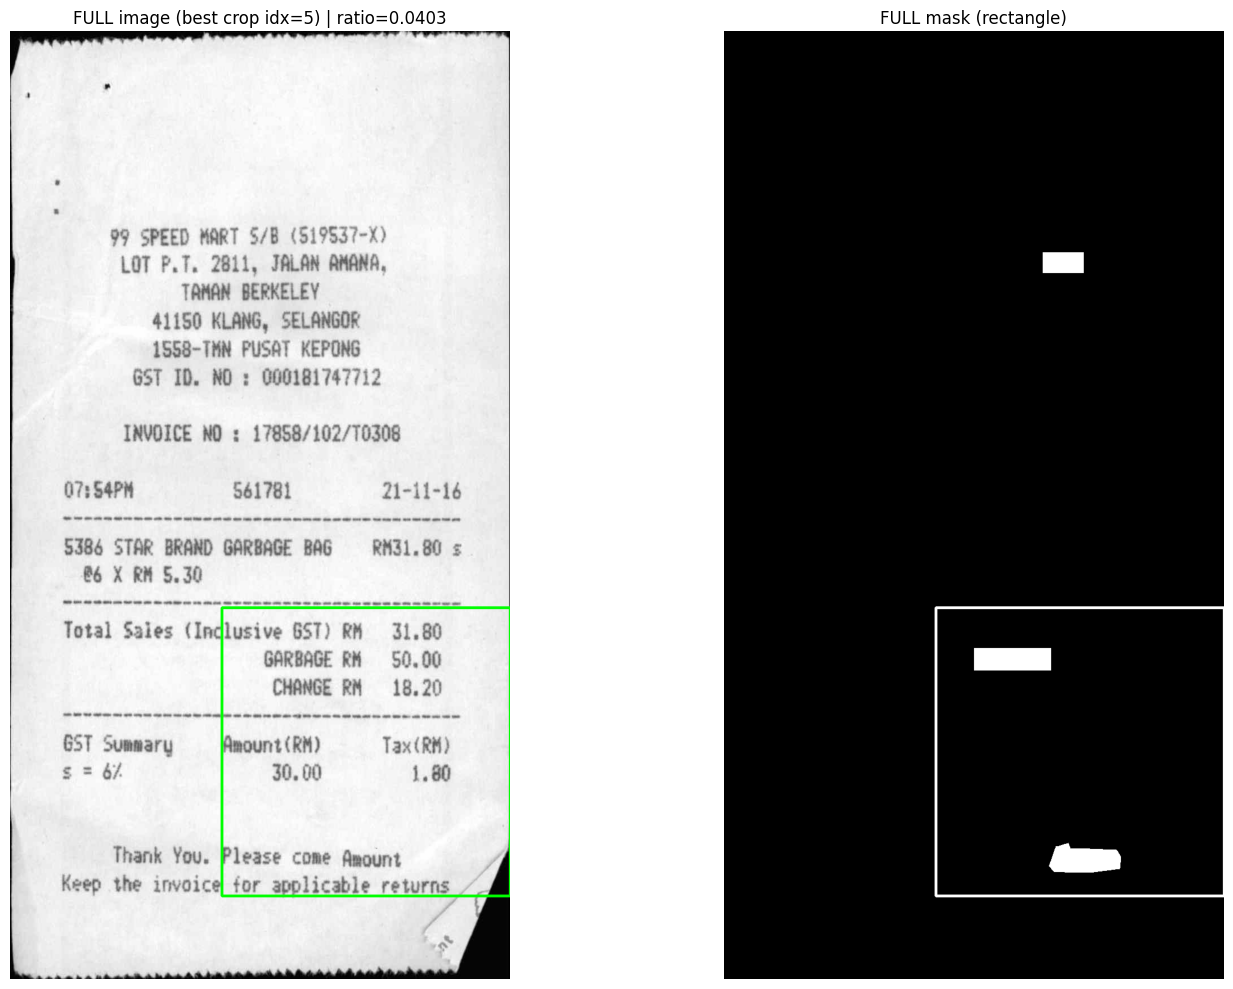

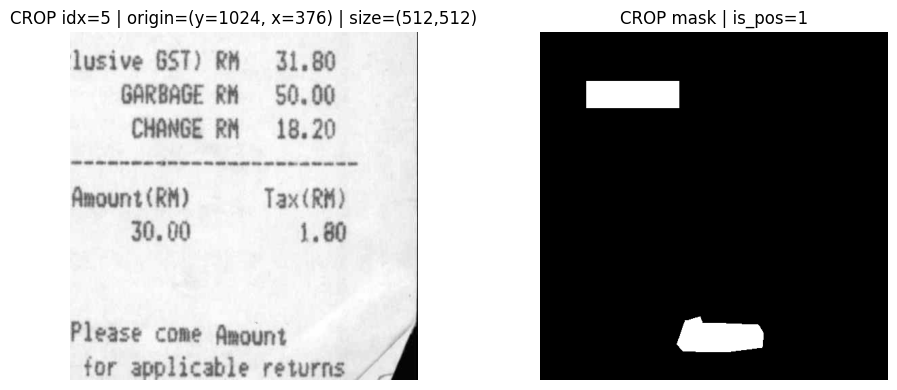

In [41]:
result = show_best_crop_only(
    image_path=train_path_cpmv,
    image_np=train_img_cpmv,
    mask_np=train_mask_cpmv,
    crop_size=(512, 512),
    stride=512,  
    pick_mode="max", # higher tampered_ratio
)

In [42]:
def save_bestcrop_from_result(
    result: dict,
    out_dir: str | Path,
    stem: str = "sample",
    save_mask: bool = True,
):
    """
    Save the selected best crop and optionally its mask.

    Args:
        result: Output dictionary from show_best_crop_only.
                Expected to contain result["crop"] = (img_crop, mask_crop).
        out_dir: Output directory.
        stem: Base filename stem.
        save_mask: Whether to save the crop mask.

    Saves:
        - <stem>_crop.jpg
        - <stem>_bestcrop_mask.png (if save_mask=True)

    Returns:
        A dictionary containing:
            - img_bestcrop_path
            - mask_bestcrop_path
    """
    
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    img_crop, mask_crop = result["crop"]  # img: HWC uint8, mask: HW int16/-1/0/1

    # Save image crop
    img_bestcrop_path = out_dir / f"{stem}_crop.jpg"
    Image.fromarray(img_crop.astype(np.uint8)).save(
        str(img_bestcrop_path), 
        quality=100, 
        subsampling=0,
    )

    mask_bestcrop_path = None
    if save_mask:
        # Convert mask to binary 0/255 for visualization and saving
        # Keep ignored pixels (-1) as 0
        m = mask_crop.copy()
        m[m < 0] = 0
        m = (m > 0).astype(np.uint8) * 255
        mask_bestcrop_path = out_dir / f"{stem}_bestcrop_mask.png"
        Image.fromarray(m).save(str(mask_bestcrop_path))

    return {
        "img_bestcrop_path": img_bestcrop_path, 
        "mask_bestcrop_path": mask_bestcrop_path,
    }

In [43]:
saved_bestcrop = save_bestcrop_from_result(
    result=result,
    out_dir="./inspection_pngs_doctamper_rtm",
    stem=f"doctamper_{train_image_name_cpmv}",
)
print(saved_bestcrop)

{'img_bestcrop_path': PosixPath('outputs_check_channels/doctamper_cpmv_2015_crop.jpg'), 'mask_bestcrop_path': PosixPath('outputs_check_channels/doctamper_cpmv_2015_bestcrop_mask.png')}


In [44]:
def load_bestcrop(image_bestcrop_path: str | Path, mask_bestcrop_path: str | Path):
    """
    Load a saved best crop and its mask from disk.

    Args:
        image_bestcrop_path: Path to the saved crop image.
        mask_bestcrop_path: Path to the saved crop mask.

    Returns:
        img_bestcrop: RGB crop image as HWC uint8.
        mask_bestcrop: Crop mask as HW int16 in {0, 1}.
    """
    
    image_bestcrop_path = Path(image_bestcrop_path)
    mask_bestcrop_path = Path(mask_bestcrop_path)

    # Load image crop
    img = Image.open(image_bestcrop_path).convert("RGB")
    img_bestcrop = np.array(img, dtype=np.uint8)

    # Load mask crop
    if mask_bestcrop_path.exists():
        mask = Image.open(mask_bestcrop_path).convert("L")
        mask_bestcrop = np.array(mask, dtype=np.uint8)
        mask_bestcrop = (mask_bestcrop > 0).astype(np.int16)  # 0/1
    else:
        mask_bestcrop = np.zeros(img_bestcrop.shape[:2], dtype=np.int16)

    return img_bestcrop, mask_bestcrop

In [45]:
train_img_cpmv_bestcrop, train_mask_cpmv_bestcrop = load_bestcrop(
    image_bestcrop_path=saved_bestcrop["img_bestcrop_path"],
    mask_bestcrop_path=saved_bestcrop["mask_bestcrop_path"],
)

print(train_img_cpmv_bestcrop.shape, train_img_cpmv_bestcrop.dtype)
print(train_mask_cpmv_bestcrop.shape, train_mask_cpmv_bestcrop.dtype)

(512, 512, 3) uint8
(512, 512) int16


In [46]:
pep_np_bestcrop = compute_pep_from_original_jpeg(
    img_path=saved_bestcrop["img_bestcrop_path"],
    origin=(0,0),         
    crop_size=(512,512),
    qf_pep=90
)

print("pep_np_bestcrop:", pep_np_bestcrop.shape, pep_np_bestcrop.dtype, "min/max:", pep_np_bestcrop.min(), pep_np_bestcrop.max())

<class 'list'> 1
<class 'list'> 1
DCT_y shape: (512, 512)
qt_y shape: (8, 8)
crop_size: (512, 512)
origin: (0, 0)
pep_np_bestcrop: (512, 512) float32 min/max: 0.0 1.0


In [47]:
ela_np_bestcrop = compute_ela(train_img_cpmv_bestcrop, qf_ela=89)

In [48]:
aux_bestcrop = compute_hp_edge(train_img_cpmv_bestcrop)

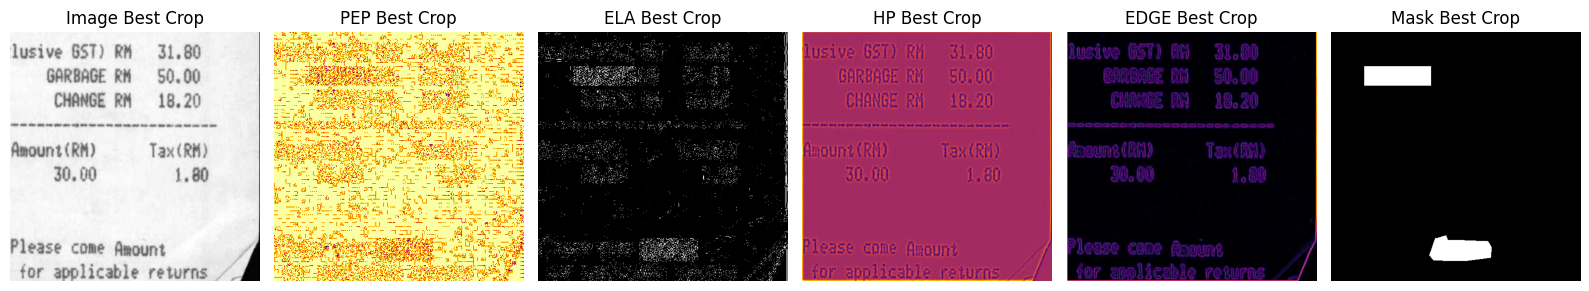

saved to: outputs_check_channels/rtm_pep_ela_2aux_bestcrop_visualization_cpmv_2015.png


In [49]:
hp_bestcrop = aux_bestcrop[:,0:1]
edge_bestcrop = aux_bestcrop[:,1:2]

plt.figure(figsize=(16,4))
plt.subplot(1,6,1); plt.imshow(train_img_cpmv_bestcrop); plt.title("Image Best Crop"); plt.axis("off")
plt.subplot(1,6,2); plt.imshow(pep_np_bestcrop, cmap="inferno"); plt.title("PEP Best Crop"); plt.axis("off")
plt.subplot(1,6,3); plt.imshow(ela_np_bestcrop, cmap="inferno"); plt.title("ELA Best Crop"); plt.axis("off")
plt.subplot(1,6,4); plt.imshow(hp_bestcrop[0,0].detach().cpu(), cmap="inferno"); plt.title("HP Best Crop"); plt.axis("off")
plt.subplot(1,6,5); plt.imshow(edge_bestcrop[0,0].detach().cpu(), cmap="inferno"); plt.title("EDGE Best Crop"); plt.axis("off")
plt.subplot(1,6,6); plt.imshow(train_mask_cpmv_bestcrop, cmap="gray"); plt.title("Mask Best Crop"); plt.axis("off")

plt.tight_layout()

save_path = "inspection_pngs_doctamper_rtm/rtm_pep_ela_2aux_bestcrop_visualization_cpmv_2015.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")

plt.show()
print("saved to:", save_path)

In [50]:
def sweep_qf2_qf3_grid_rtm(
    img_rgb: np.ndarray,
    mask: np.ndarray,
    qf2_list=(80, 85, 90, 95, 97, 98, 99, 100),
    qf3_list=(80, 85, 90, 95, 100),
    dpi=160,
    save_dir=None,
    save_prefix="sweep_",
    save_format="png",
    show=True,
):
    """
    Run a sweep over:
        - QF2: JPEG recompression quality factor applied first to the RGB image
        - QF3: quality factor used afterwards in PEP and ELA computation

    For each QF2, the function displays 2 rows:
        1. PEP computed with qf_pep = QF3
        2. ELA computed with qf_ela = QF3

    Layout:
        - columns  -> QF3 values
        - row groups -> one group of 2 rows per QF2
          [PEP, ELA]

    Pipeline:
        RGB -> JPEG(QF2) -> PEP(QF3) + ELA(QF3)

    Args:
        img_rgb: RGB image as a NumPy array.
        mask: Input mask (not used in the current visualization).
        qf2_list: List of JPEG input quality factors to evaluate.
        qf3_list: List of PEP/ELA quality factors to evaluate.
        dpi: Output figure DPI.
        save_dir: Directory where the figure will be saved.
        save_prefix: Prefix used for the output filename.
        save_format: Output image format.
        show: Whether to display the figure.

    Returns:
        saved_path: Output file path if saved, otherwise None.
    """

    qf2_list = list(qf2_list)
    qf3_list = list(qf3_list)

    n_qf2 = len(qf2_list)
    n_qf3 = len(qf3_list)

    nrows = 2 * n_qf2   # PEP / ELA for each QF2
    ncols = n_qf3

    fig, ax = plt.subplots(
        nrows,
        ncols,
        figsize=(3.6 * ncols, 2.2 * nrows),
        dpi=dpi,
    )

    if nrows == 1 and ncols == 1:
        ax = np.array([[ax]])
    elif nrows == 1:
        ax = np.expand_dims(ax, 0)
    elif ncols == 1:
        ax = np.expand_dims(ax, 1)

    tmp_dir = Path("/media/general_storage6/rmastorage/tmp_aux")
    tmp_dir.mkdir(parents=True, exist_ok=True)

    for i, qf2 in enumerate(qf2_list):
        tmp_path = None

        try:
            # -------------------------------------------------------------
            # Step 1: Save RGB image once as JPEG(QF2)
            # -------------------------------------------------------------
            tmp = tempfile.NamedTemporaryFile(
                suffix=".jpg",
                dir=tmp_dir,
                delete=False,
            )
            tmp_path = tmp.name
            tmp.close()

            Image.fromarray(img_rgb.astype(np.uint8)).convert("RGB").save(
                tmp_path,
                "JPEG",
                quality=int(qf2),
                subsampling=0,
                optimize=False,
            )

            # Load compressed image for ELA
            img_qf2 = np.array(Image.open(tmp_path).convert("RGB"), dtype=np.uint8)

            # Extract JPEG info from JPEG(QF2)
            dct_coef, qtables = utils.get_jpeg_info(tmp_path, 1)
            dct_y = np.array(dct_coef[0])
            qt_y = qtables[0]

            row_pep = 2 * i + 0
            row_ela = 2 * i + 1

            for j, qf3 in enumerate(qf3_list):
                # ---------------------------------------------------------
                # Step 2: Compute PEP with qf_pep = QF3
                # ---------------------------------------------------------
                pep_t = DocForgeryELAPEPDataset.pep_features(
                    image_path=Path(tmp_path),
                    dct=dct_y,
                    qtable=qt_y,
                    origin=(0, 0),
                    crop_size=None,
                    qf_pep=int(qf3),
                )
                pep = pep_t[0].detach().cpu().numpy()

                # ---------------------------------------------------------
                # Step 3: Compute ELA with qf_ela = QF3
                # ---------------------------------------------------------
                pil = Image.fromarray(img_qf2.astype(np.uint8)).convert("RGB")

                ela_t = DocForgeryELAPEPDataset.ela_features(
                    image=pil,
                    origin=(0, 0),
                    crop_size=None,
                    qf_ela=int(qf3),   # to match dataset: self.QF - 1
                )
                
                ela = ela_t[0].detach().cpu().numpy()

                # ---------------------------------------------------------
                # Plot PEP / ELA
                # ---------------------------------------------------------
                ax[row_pep, j].imshow(pep, cmap="magma")
                ax[row_pep, j].axis("off")

                ax[row_ela, j].imshow(ela, cmap="magma")
                ax[row_ela, j].axis("off")

                # Titles only on the first QF2 block
                if i == 0:
                    ax[row_pep, j].set_title(f"QF3={qf3}", fontsize=10, pad=6)

            # -------------------------------------------------------------
            # Row labels (left side)
            # -------------------------------------------------------------
            ax[row_pep, 0].text(
                -0.18, 0.5, f"PEP\nQF2={qf2}",
                transform=ax[row_pep, 0].transAxes,
                ha="right",
                va="center",
                fontsize=10,
                fontweight="bold",
            )

            ax[row_ela, 0].text(
                -0.18, 0.5, f"ELA\nQF2={qf2}",
                transform=ax[row_ela, 0].transAxes,
                ha="right",
                va="center",
                fontsize=10,
                fontweight="bold",
            )

        finally:
            if tmp_path is not None and Path(tmp_path).exists():
                try:
                    Path(tmp_path).unlink()
                except Exception:
                    pass

    #fig.suptitle(
    #    "RTM Sweep | JPEG input QF2 x PEP/ELA QF3",
    #    fontsize=16,
    #    y=0.995,
    #)
    plt.tight_layout(rect=[0, 0, 1, 0.985])

    saved_path = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        qf2_min, qf2_max = min(qf2_list), max(qf2_list)
        qf3_min, qf3_max = min(qf3_list), max(qf3_list)

        out_name = (
            f"{save_prefix}"
            f"qf2_{qf2_min}-{qf2_max}_"
            f"qf3_{qf3_min}-{qf3_max}."
            f"{save_format}"
        )

        out_path = save_dir / out_name
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        saved_path = str(out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path

In [51]:
saved_path = sweep_qf2_qf3_grid_rtm(
    img_rgb=train_img_cpmv,
    mask=train_mask_cpmv,
    qf2_list=(97, 98, 99, 100),
    qf3_list=(80, 85, 88, 89, 90, 95),
    save_dir="inspection_pngs_doctamper_rtm",
    save_prefix="rtm_cpmv_2015_sweep_",
    show=False,
)

print(saved_path)

outputs_check_channels/rtm_cpmv_2015_sweep_qf2_97-100_qf3_80-95.png
